# TomaLink AI & Machine Learning
## Group 6 Project

### Predicting Post-Harvest Tomato Losses Using Machine Learning

# Project Overview

### Business Problem

Post-harvest tomato losses remain a major challenge in Nigeria due to poor storage practices, transportation challenges, unfavorable environmental conditions, and market-related factors. These losses reduce farmers' income, increase food waste, and affect the agricultural supply chain.

### Project Goal

The goal of this project is to apply Artificial Intelligence and Machine Learning techniques to analyze factors influencing post-harvest tomato losses and develop predictive models that estimate tomato loss percentage.

### AI & Machine Learning Objectives

- Explore and understand the tomato supply chain dataset.
- Perform data preprocessing and exploratory data analysis.
- Identify important factors influencing tomato loss percentage.
- Build and evaluate multiple machine learning regression models.
- Select the best-performing model for predicting tomato loss percentage.

# Machine Learning Workflow

This notebook follows the CRISP-DM (Cross-Industry Standard Process for Data Mining) methodology.

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Exploratory Data Analysis (EDA)
5. Feature Selection
6. Model Development
7. Model Evaluation
8. AI Recommendations
9. Conclusion

In [1]:
# Import the libraries needed for this project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


# Loading the Dataset

The dataset is stored in CSV (.csv) format. The Pandas library is used to load the dataset into Python, making it available for data exploration, preprocessing, visualization, and machine learning analysis.

In [2]:
# Load the dataset

df = pd.read_csv("Tomato_Supply_raw_Dataset  (1)")

print("Dataset loaded successfully!")

Dataset loaded successfully!


# Inspecting the Dataset

Before developing machine learning models, it is important to inspect the dataset. This step helps us understand the structure of the data, identify the available features, verify the data types, and detect any missing or inconsistent values that may affect the analysis.

In [3]:
# Display the first five rows

df.head()

,Farmer_ID,State,LGA,Latitude,Longitude,Farm_Size_ha,Tomato_Variety,Harvest_Date,Harvest_kg,Harvest_Season,...,Quantity_Lost_kg,Loss_Cause,Revenue_NGN,Estimated_Profit_NGN,Loss_Percentage,Spoilage_Risk,Inventory_Status,Delivery_Status,GPS_Tracked,Record_Source
0,F00001,Jigawa,Hadejia,12.41735,9.41433,2.17,Roma,2025-04-23,5626,Dry,...,1519.0,Poor Packaging,"NGN 2,694,178.88","NGN 1,141,402.88",27,Medium,Sold,Pending,No,"Synthetic (based on FAOSTAT, NBS, literature)"
1,F00002,Jigawa,Hadejia,12.14305,9.48371,3.09,Beske,2025-12-25,5240,Dry,...,1834.0,Poor Packaging,"NGN 1,917,578.00","NGN 738,578.00",35,Medium,In Stock,Delayed,Yes,"Synthetic (based on FAOSTAT, NBS, literature)"
2,F00003,Bauchi,Toro,10.04305,9.55617,1.15,UC82B,2025-02-09,3241,Dry,...,1004.7,Mechanical Damage,"NGN 2,093,167.44","NGN 1,383,388.44",31,Medium,In Stock,Delivered,No,"Synthetic (based on FAOSTAT, NBS, literature)"
3,F00004,Plateau,Bokkos,9.31380,8.80475,3.97,UC82B,2025-09-08,4409,Wet,...,925.9,Mechanical Damage,"NGN 3,563,221.53","NGN 2,743,147.53",21,Medium,In Stock,Delayed,No,"Synthetic (based on FAOSTAT, NBS, literature)"
4,F00005,Jigawa,Kazaure,12.42792,9.54013,2.36,Tropimech,2025-12-20,1343,Dry,...,416.3,Pests,"NGN 991,536.90","NGN 612,810.90",31,Medium,Sold,Delayed,Yes,"Synthetic (based on FAOSTAT, NBS, literature)"


In [4]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 40 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Farmer_ID                5000 non-null   object 
 1   State                    5000 non-null   object 
 2   LGA                      5000 non-null   object 
 3   Latitude                 5000 non-null   float64
 4   Longitude                5000 non-null   float64
 5   Farm_Size_ha             5000 non-null   float64
 6   Tomato_Variety           5000 non-null   object 
 7   Harvest_Date             5000 non-null   object 
 8   Harvest_kg               5000 non-null   int64  
 9   Harvest_Season           5000 non-null   object 
 10  Storage_Method           5000 non-null   object 
 11  Storage_Days             5000 non-null   int64  
 12  Warehouse_ID             5000 non-null   object 
 13  Cold_Storage_Available   5000 non-null   object 
 14  Transport_ID            

In [21]:
# Generate summary statistics

df.describe()

,Latitude,Longitude,Farm_Size_ha,Harvest_kg,Storage_Days,Transport_km,Travel_Hours,Temperature_C,Humidity_pct,Rainfall_mm,Market_Demand_kg,Quantity_Sold_kg,Quantity_Lost_kg,Loss_Percentage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.00000
mean,11.015694,8.895020,5.279792,3149.802600,3.546400,203.464600,6.296040,31.412540,65.399200,19.990780,10443.280600,2437.44362,712.358940,22.75260
std,1.131397,0.763821,2.743641,1634.012166,2.279405,113.105488,3.301718,4.376174,17.699799,11.459266,5679.604037,1334.92433,551.885946,11.57168
min,9.000810,7.400340,0.500000,302.000000,0.000000,5.000000,0.500000,24.000000,35.000000,0.000000,507.000000,153.00000,6.000000,2.00000
25%,10.154782,8.381493,2.900000,1742.750000,2.000000,104.750000,3.500000,27.500000,50.000000,10.100000,5602.750000,1306.02500,279.675000,14.00000
50%,11.063200,8.927035,5.300000,3157.500000,4.000000,203.000000,6.300000,31.400000,66.000000,19.950000,10497.500000,2391.15000,579.500000,22.00000
75%,12.117150,9.580805,7.650000,4575.250000,6.000000,301.000000,9.100000,35.100000,81.000000,29.825000,15465.250000,3473.25000,1024.250000,31.00000
max,12.699600,10.099800,10.000000,6000.000000,7.000000,400.000000,12.000000,39.000000,95.000000,40.000000,20000.000000,5874.10000,3325.200000,59.00000


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the characteristics of the dataset by identifying patterns, trends, and relationships among variables before building machine learning models.

## Distribution of Storage Methods

This chart shows how different storage methods are distributed across the dataset. Storage practices can significantly influence post-harvest tomato losses.

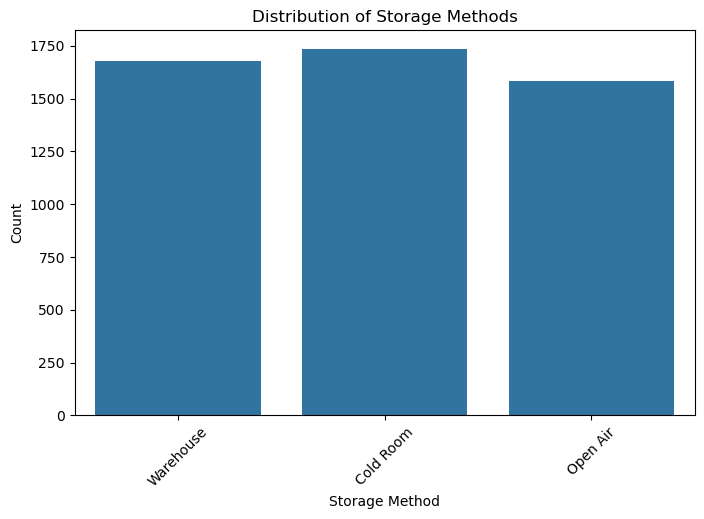

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x="Storage_Method", data=df)

plt.title("Distribution of Storage Methods")
plt.xlabel("Storage Method")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Relationship Between Temperature and Loss Percentage

This scatter plot explores the relationship between storage temperature and tomato loss percentage. It helps determine whether higher temperatures are associated with increased post-harvest losses.

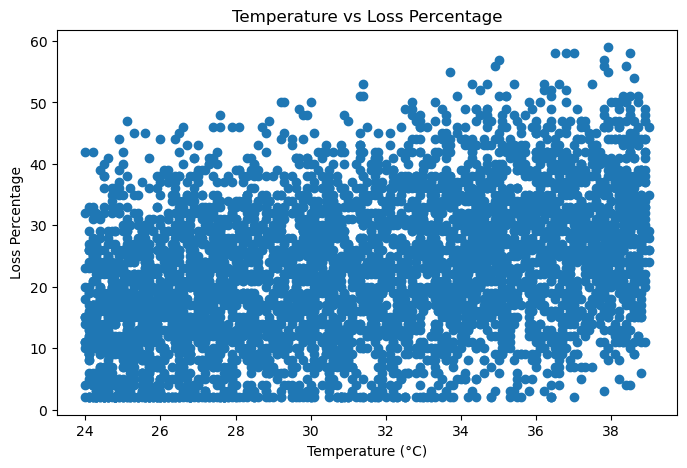

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(df["Temperature_C"], df["Loss_Percentage"])

plt.title("Temperature vs Loss Percentage")
plt.xlabel("Temperature (°C)")
plt.ylabel("Loss Percentage")

plt.show()

## Distribution of Road Conditions

Road conditions can affect transportation efficiency and contribute to tomato spoilage during transit. This chart shows the distribution of road conditions recorded in the dataset.

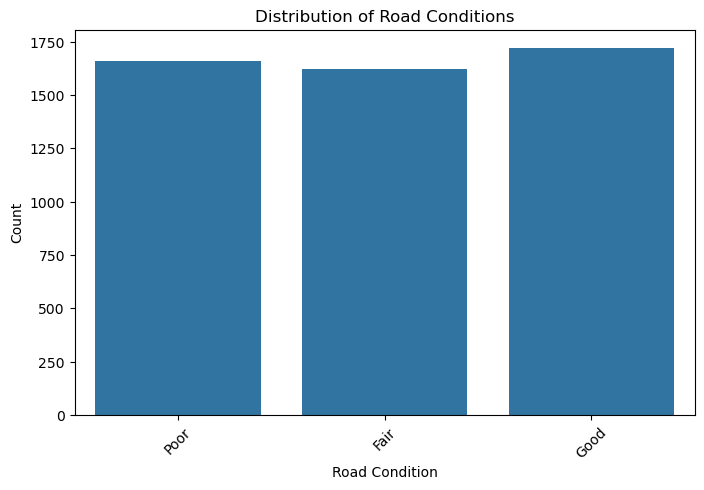

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(x="Road_Condition", data=df)

plt.title("Distribution of Road Conditions")
plt.xlabel("Road Condition")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Feature Importance

Feature importance shows how much each selected feature contributes to predicting tomato loss percentage. Understanding the most influential factors can help farmers, buyers, and logistics providers focus on areas that have the greatest impact on reducing post-harvest losses.

In [25]:
# Display feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                   Feature  Importance
3             Storage_Days    0.325508
2           Storage_Method    0.291000
8           Road_Condition    0.162247
10           Temperature_C    0.159684
13        Market_Demand_kg    0.008354
1               Harvest_kg    0.008064
0             Farm_Size_ha    0.008036
12             Rainfall_mm    0.007634
6             Transport_km    0.007525
7             Travel_Hours    0.007221
11            Humidity_pct    0.007124
5             Vehicle_Type    0.002223
9                Packaging    0.002116
14              Buyer_Type    0.002065
4   Cold_Storage_Available    0.001198


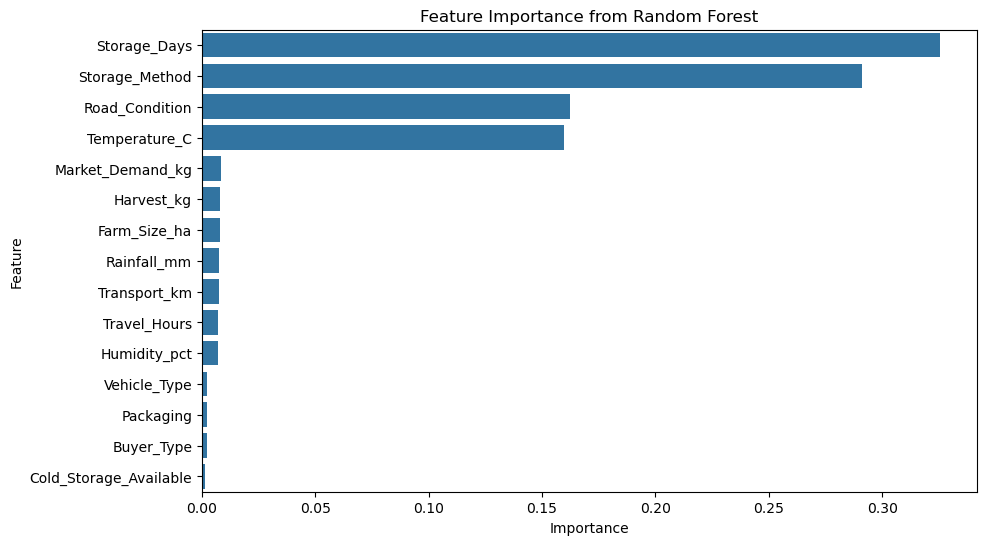

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Data Preprocessing

Data preprocessing prepares the dataset for machine learning by checking for missing values, identifying duplicate records, verifying data quality, and converting categorical variables into numerical values that machine learning algorithms can process effectively.

## Checking for Missing Values

Missing values can affect the accuracy and performance of machine learning models. Before proceeding with data analysis and model development, it is important to check whether the dataset contains any missing values that require cleaning or preprocessing.

In [6]:
df.isnull().sum()

Farmer_ID                  0
State                      0
LGA                        0
Latitude                   0
Longitude                  0
Farm_Size_ha               0
Tomato_Variety             0
Harvest_Date               0
Harvest_kg                 0
Harvest_Season             0
Storage_Method             0
Storage_Days               0
Warehouse_ID               0
Cold_Storage_Available     0
Transport_ID               0
Vehicle_Type               0
Transport_km               0
Travel_Hours               0
Transport_Cost_NGN         0
Road_Condition             0
Packaging                  0
Temperature_C              0
Humidity_pct               0
Rainfall_mm                0
Buyer_Type                 0
Buyer_ID                   0
Market                     0
Market_Demand_kg           0
Market_Price_NGN_per_kg    0
Quantity_Sold_kg           0
Quantity_Lost_kg           0
Loss_Cause                 0
Revenue_NGN                0
Estimated_Profit_NGN       0
Loss_Percentag

## Checking for Duplicate Records

Duplicate records can reduce the quality of data analysis and machine learning models by introducing redundant information. Therefore, it is important to verify whether the dataset contains duplicate entries before proceeding with further analysis.

In [7]:
df.duplicated().sum()

np.int64(0)

## Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical variables are converted into numerical values using Label Encoding, enabling the models to process the dataset effectively.

In [8]:
df.dtypes

Farmer_ID                   object
State                       object
LGA                         object
Latitude                   float64
Longitude                  float64
Farm_Size_ha               float64
Tomato_Variety              object
Harvest_Date                object
Harvest_kg                   int64
Harvest_Season              object
Storage_Method              object
Storage_Days                 int64
Warehouse_ID                object
Cold_Storage_Available      object
Transport_ID                object
Vehicle_Type                object
Transport_km                 int64
Travel_Hours               float64
Transport_Cost_NGN          object
Road_Condition              object
Packaging                   object
Temperature_C              float64
Humidity_pct                 int64
Rainfall_mm                float64
Buyer_Type                  object
Buyer_ID                    object
Market                      object
Market_Demand_kg             int64
Market_Price_NGN_per

In [9]:
df.select_dtypes(include="object").columns

Index(['Farmer_ID', 'State', 'LGA', 'Tomato_Variety', 'Harvest_Date',
       'Harvest_Season', 'Storage_Method', 'Warehouse_ID',
       'Cold_Storage_Available', 'Transport_ID', 'Vehicle_Type',
       'Transport_Cost_NGN', 'Road_Condition', 'Packaging', 'Buyer_Type',
       'Buyer_ID', 'Market', 'Market_Price_NGN_per_kg', 'Loss_Cause',
       'Revenue_NGN', 'Estimated_Profit_NGN', 'Spoilage_Risk',
       'Inventory_Status', 'Delivery_Status', 'GPS_Tracked', 'Record_Source'],
      dtype='object')

# Feature Selection

Feature selection is the process of choosing the variables that will be used to train the machine learning models. The selected features should be relevant to the prediction task, while the target variable represents the value the model is expected to predict.

In [12]:
# Select the features (X)

X = df[[
    "Farm_Size_ha",
    "Harvest_kg",
    "Storage_Method",
    "Storage_Days",
    "Cold_Storage_Available",
    "Vehicle_Type",
    "Transport_km",
    "Travel_Hours",
    "Road_Condition",
    "Packaging",
    "Temperature_C",
    "Humidity_pct",
    "Rainfall_mm",
    "Market_Demand_kg",
    "Buyer_Type"
]].copy()

# Select the target variable (y)

y = df["Loss_Percentage"]

## Encoding Categorical Features

Several of the selected features are categorical and must be converted into numerical values before training the machine learning models. Label Encoding is applied to transform these categorical variables into numeric representations while preserving all records in the dataset.

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
    "Storage_Method",
    "Cold_Storage_Available",
    "Vehicle_Type",
    "Road_Condition",
    "Packaging",
    "Buyer_Type"
]

for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column])

# Splitting the Dataset

Before training the machine learning models, the dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate how well the models perform on unseen data. In this project, 80% of the data is used for training and 20% for testing.

In [14]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (4000, 15)
Testing set: (1000, 15)


# Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values. In this project, it is used to predict the tomato loss percentage based on selected farming, storage, transportation, environmental, and market-related features.

In [15]:
# Train the Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Make predictions

y_pred_lr = linear_model.predict(X_test)

## Linear Regression Model Evaluation

The performance of the Linear Regression model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and the R² Score. These metrics help determine how accurately the model predicts tomato loss percentage.

In [16]:
# Evaluate the Linear Regression model

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("R² Score:", r2_lr)

Linear Regression Results
MAE: 5.628885281677612
MSE: 46.90162815233233
R² Score: 0.6510953458870647


# Decision Tree Regressor

Decision Tree Regression is a supervised machine learning algorithm that predicts continuous values by learning decision rules from the training data. It captures non-linear relationships between features and the target variable, making it useful for modeling complex patterns in tomato loss percentage.

In [17]:
# Train the Decision Tree Regressor

decision_tree = DecisionTreeRegressor(random_state=42)

decision_tree.fit(X_train, y_train)

# Make predictions

y_pred_dt = decision_tree.predict(X_test)

## Decision Tree Model Evaluation

The Decision Tree Regressor is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and the R² Score. These metrics are used to measure how accurately the model predicts tomato loss percentage on the testing dataset.

In [18]:
# Evaluate the Decision Tree Regressor

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("R² Score:", r2_dt)

Decision Tree Results
MAE: 3.727
MSE: 21.359
R² Score: 0.8411088313822727


# Random Forest Regressor

Random Forest Regression is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is widely used for regression problems because it can model complex relationships and produce more robust predictions.

In [19]:
# Train the Random Forest Regressor

random_forest = RandomForestRegressor(random_state=42)

random_forest.fit(X_train, y_train)

# Make predictions

y_pred_rf = random_forest.predict(X_test)

## Random Forest Model Evaluation

The Random Forest Regressor is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and the R² Score. These evaluation metrics are used to assess the model's prediction accuracy and compare its performance with the other regression models.

In [20]:
# Evaluate the Random Forest Regressor

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE: 2.8244
MSE: 11.292653999999999
R² Score: 0.9159931180834471


# Model Comparison

Three machine learning regression models were trained and evaluated to predict the **Loss Percentage** of tomatoes.

| Model | MAE | MSE | R² Score |
|-------|------:|------:|------:|
| Linear Regression | 5.6289 | 46.9016 | 0.6511 |
| Decision Tree Regressor | 3.7270 | 21.3590 | 0.8411 |
| Random Forest Regressor | **2.8244** | **11.2927** | **0.9160** |

The Random Forest Regressor achieved the best overall performance. It recorded the lowest Mean Absolute Error (MAE), the lowest Mean Squared Error (MSE), and the highest R² Score (0.9160). This indicates that the model can accurately predict tomato loss percentage and is the most suitable model for this project.

# AI Recommendations

Based on the machine learning analysis, the following recommendations can help reduce post-harvest tomato losses:

- Improve storage methods to minimize spoilage during storage.
- Increase access to cold storage facilities for farmers.
- Optimize transportation routes and reduce travel time.
- Use appropriate packaging materials to protect tomatoes during transit.
- Monitor environmental factors such as temperature and humidity throughout the supply chain.
- Use machine learning predictions to identify high-risk situations and support better decision-making for farmers, buyers, and logistics providers.

# Conclusion

This project demonstrated how Artificial Intelligence and Machine Learning can be applied to predict post-harvest tomato losses using data from the TomaLink supply chain.

The dataset was explored, preprocessed, and analyzed before training three regression models: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

Among the three models, the Random Forest Regressor achieved the best performance with an R² Score of **0.9160**, indicating strong predictive accuracy. This model can help estimate tomato loss percentage based on farming, storage, transportation, environmental, and market-related factors.

The findings from this project can support farmers, buyers, and logistics providers in making informed decisions that reduce post-harvest losses, improve operational efficiency, and strengthen the agricultural supply chain.